# NicheNet training: case-control study example

In this case study, we will use mouse NICHE-seq data from Medaglia et al. (2017) to explore intercellular communication in the T cell area in the inguinal lymph node before and 72 hours after lymphocytic choriomeningitis virus (LCMV) infection. Specifically, we will prioritize which ligands can best explain the downstream changes after LCMV infection in CD8 T cells as the receiver population. This dataset contains 13,541 genes and 5,027 cells from 6 cell populations: CD4 T cells (including regulatory T cells), CD8 T cells, B cells, NK cells, dendritic cells (DCs) and inflammatory monocytes.

The ligand-target prior model is a matrix describing the potential that a ligand may regulate a target gene, and it is used to run the ligand activity analysis. The ligand-receptor network contains information on potential ligand-receptor bindings, and it is used to identify potential ligands. Finally, the weighted ligand-receptor network contains weights representing the potential that a ligand will bind to a receptor, and it is used for visualization.

These networks were translated from human to mouse gene names using one-to-one orthologs when feasible, and one-to-many conversion was allowed when necessary (for instance, when one human gene symbol corresponded to two mouse gene symbols). Users that are interested in building prior models for other organisms can either create an organism-specific model using data sources relevant to that organism, or use the existing human NicheNet model to convert human gene symbols to their corresponding one-to-one orthologs in the organism of interest. However, this decision depends on one hand, the availability of data for the organism of interest and on the other, the homology between humans and the organism of interest. For instance, using the human model and converting gene symbols might work for primates, but creating a new model from species-specific data sources is better suited for organisms like Drosophila.

<img src="./images/protocols/figure2.png" style="width:70.0%" />

In [1]:
from nichenetpy.utils import (
    combine_by_key,
    combine_dicts,
    subset_matrix,
    ligand_activities_df,
    read_csv_cols,
    decomplexify
)
from nichenetpy.extraction import (
    get_expressed_genes,
    subset_ann,
    get_weighted_ligand_receptor_links,
    get_lfc_celltype
)
from nichenetpy.gene_symbol import mouse_alias_info
from nichenetpy.visualization import (
    prepare_ligand_target_visualization,
    prepare_ligand_receptor_visualization,
    heatmap_2d,
    heatmap_1d,
    assign_ligands_to_celltype,
    get_ligand_signaling_path,
    visualize_ligand_signaling_graph
)
from nichenetpy.metrics import group_metrics, calculate_metrics
from nichenetpy.wrappers import (
    run_nichenet,
    create_ligand_links_circos_plot,
    generate_info_tables,
    calculate_fraction_top_predicted,
    calculate_fraction_top_predicted_fisher,
    get_top_predicted_genes
)
from nichenetpy.prioritization import (
    generate_prioritization_table,
    process_table_to_ic,
    calculate_de,
    get_avg_exp
)
from nichenetpy.model_construction import (
    construct_weighted_networks,
    construct_ligand_target_matrix,
    apply_hub_correction
)
from nichenetpy.prediction import assess_rf_class_probabilities

from itertools import cycle, chain, repeat
from liana.resource import select_resource

import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import os
import requests
import pickle
import pandas as pd
import session_info

Download the model files

In [2]:
filename = "nichenet_mouse.pkl"
file_path = os.path.join("./tutorial_files", filename)
if not os.path.exists(file_path):
    res = requests.get(f"https://zenodo.org/records/14887637/files/{filename}")
    with open(file_path, "wb") as file:
        file.write(res.content)

Download the AnnData object

In [3]:
data_path = os.path.normpath("./tutorial_files/AnnData")
if not os.path.exists(data_path):
    os.makedirs(data_path)
filename = "annData3531889.h5"
file_path = os.path.join(data_path, filename)
if not os.path.exists(file_path):
    res = requests.get(f"https://zenodo.org/records/14859451/files/{filename}")
    with open(file_path, "wb") as file:
        file.write(res.content)

### Feature extraction

1) Read in the model networks

In [4]:
with open("./tutorial_files/nichenet_mouse.pkl", "rb") as file:
    model = pickle.loads(file.read())
predictor = model["predictor"]
lr_network = model["lr_network"]
lr_sig = model["lr_sig"]
gr = model["gr"]

2) Read in the AnnData object

In [5]:
ann = anndata.io.read_h5ad(os.path.join(data_path, "annData3531889.h5"))
ann.var_names = ann.var["gene"]
ann

AnnData object with n_obs × n_vars = 5027 × 13541
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nGene', 'nUMI', 'aggregate', 'res.0.6', 'celltype'
    var: 'gene'
    layers: 'counts', 'data', 'scale.data'

3) For expression data with older gene symbols, convert them to more recent gene symbols. 

In [6]:
mouse_alias_info.alias_to_symbol(ann)

4) Define a "receiver" cell population. The receiver cell population can only consist of one cell type.

In [7]:
receiver = "CD8 T" 

5) Determine which genes are expressed in the receiver cell population. The function get_expressed_genes considers genes to be expressed if they have non-zero counts in a certain percentage of the cell population (by default set at 10%). Here, we have lowered the threshold to 5% (pct) as some of the ligands and receptors are very lowly expressed. Users are also free to define expressed genes differently in a way that fits their data.

In [8]:
expressed_genes_receiver = set(get_expressed_genes(receiver, ann, 0.05))

6) Get a list of all receptors available in the ligand-receptor network, and define expressed receptors as genes that are in the ligand-receptor network and expressed in the receiver.

In [9]:
all_receptors = lr_network.get_receptors()
expressed_receptors = all_receptors.intersection(expressed_genes_receiver)


7) Define the potential ligands as all ligands whose cognate receptors are expressed.

In [10]:
potential_ligands = set(
    key for key, group in lr_network.item_iter()
    if len(group.intersection(expressed_receptors)) > 0
)

8) (Optional) For the sender-focused approach, define sender cell types and expressed genes in all populations combined. Then, filter potential ligands to those that are expressed in sender cells.

In [11]:
sender_celltypes = ("CD4 T", "Treg", "Mono", "NK", "B", "DC")
list_expressed_genes_sender = [get_expressed_genes(ct, ann, pct=0.05) for ct in sender_celltypes]
expressed_genes_sender = set(e for l in list_expressed_genes_sender for e in l)
expressed_ligands = lr_network.get_ligands().intersection(expressed_genes_sender)
potential_ligands_focused = potential_ligands.intersection(expressed_genes_sender)

9) Define the reference condition and condition of interest. The condition of interest is the condition after the CCC event has taken place, or the 'case' group in case-control studies. Here, it represents the condition after LCMV infection. Similarly, the reference condition is the state before the CCC event, often referred to as the control or steady-state condition.

In [12]:
condition_oi = "LCMV"
condition_ref = "SS"

10) Define the gene set of interest that represents the cell-cell communication event to be studied. First, create a new AnnData object that only contains the receiver cell type. Then, perform DE analysis between the treatment conditions within the receiver cell type. Finally, define the gene set of interest as significantly DE genes (i.e., genes with adjusted p-value lower than or equal to 0.05 and absolute log-fold change greater than 0.25).

By default, both genes that are up and downregulated are considered. Users can choose to focus on only one direction (typically upregulation) by removing the abs() function and adjusting the equality term to either >= 0.25 or <= -0.25 for up and downregulation, respectively. We recommend the gene set of interest to contain between 20 and 2000 genes for optimal ligand activity prediction. Moreover, the number of background genes should be sufficiently greater than those of the gene set of interest.

In [13]:
ann_receiver = subset_ann(
    ann,
    val=receiver,
    val_col="celltype",
    layers=["data", "counts"]
)
group_metrics(
    ann_receiver,
    groupby="aggregate",
    layer="data",
    min_pct=0.05,
    min_abs_lfc=0.25
)
DE_table = ann_receiver.uns["group_metrics"]
geneset = set(
    DE_table[
        (DE_table["aggregate"] == "LCMV") &
        (DE_table["pval_adj"] <= 0.05)
    ]["gene"]
)
geneset.intersection_update(predictor.get_genes())

11) Determine background genes as all the genes expressed in the receiver cell type that are also in the ligand-target matrix.

In [14]:
background_expressed_genes = predictor.get_genes().intersection(expressed_genes_receiver)

### Ligand activity analysis and downstream prediction

12) Perform the ligand activity analysis, then sort the ligands based on the area under the precision-recall curve (AUPR).

In [15]:
ligand_activities = predictor.predict_ligand_activities(
    geneset=geneset,
    background_expressed_genes=background_expressed_genes,
    potential_ligands=potential_ligands
)
ligand_activities_sorted = sorted(
    ligand_activities.items(),
    key=lambda x : (-x[1]["aupr_corrected"], x[0])
)

13) (Optional) If performing the sender-focused approach, subset the ligand activities to only contain expressed ligands. Note: When using the sender-agnostic approach, simply replace ligand_activities with ligand_activities_all in Steps 14 and 18.

In [16]:
ligand_activities_all = ligand_activities.copy()
ligand_activities_sorted_all = ligand_activities_sorted.copy()
ligand_activities = dict(
    (key, val) for key, val in ligand_activities.items() if key in potential_ligands_focused
)
ligand_activities_sorted = sorted(
    ligand_activities.items(),
    key=lambda x : (-x[1]["aupr_corrected"], x[0])
)

14) Obtain the names of the top 30 ligands.

In [17]:
best_upstream_ligands = [e[0] for e in ligand_activities_sorted[:30]]

15) (Optional) Assess the quality of predicted ligands according to Box 5.

16) Infer which genes in the gene set of interest have the highest regulatory potential for each top-ranked ligand. The function get_weighted_ligand_target_links will return genes that are in the gene set of interest and are the top n targets of a ligand (default: n = 250).

In [18]:
active_ligand_target_links = [
    predictor.get_weighted_ligand_target_links(ligand, geneset, n=200)
    for ligand in best_upstream_ligands
]
# combine weighted ligand-target links of different ligands
active_ligand_target_links = list(
    chain(
        *(zip(cycle([e["ligand"]]), e["target"], e["weight"]) for e in active_ligand_target_links)
    )
)

17) Similarly, identify which receptors have the highest interaction potential with the top-ranked ligands.

In [19]:
ligand_receptor_links = get_weighted_ligand_receptor_links(
    best_upstream_ligands,
    expressed_receptors,
    lr_network,
    lr_sig
)

### Visualizations

18) Create a heatmap of the ligand activity measure (Figure 3a).

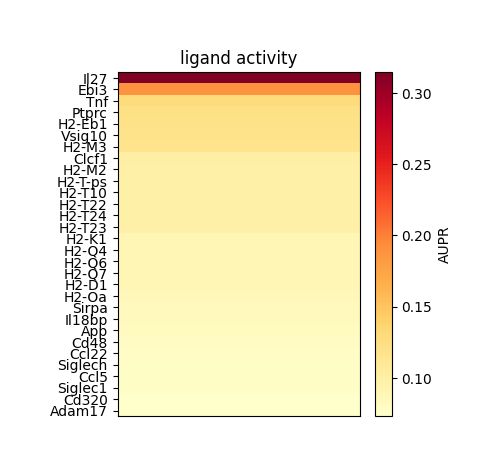

In [20]:
ligands, metrics = zip(*ligand_activities_sorted[:30])
fig, ax = heatmap_1d(
    [e["aupr_corrected"] for e in metrics],
    labels=ligands,
    title="ligand activity",
    cbar_label="AUPR",
    cmap="YlOrRd",
    figsize=(4, 4)
)
ax.invert_yaxis()
plt.show()

19) Prepare the weighted ligand-target data frame for visualization by transforming it into matrix. By default, regulatory potentials lower than the 25th percentile are set to zero for visualization clarity. This cutoff parameter can freely be tuned by the user.

In [21]:
ligand_target_vis, targets, ligands = prepare_ligand_target_visualization(
    predictor,
    active_ligand_target_links,
    cutoff=0.25
)

20) Order the rows to follow the rankings of the ligands, and the columns alphabetically (Figure 3b).

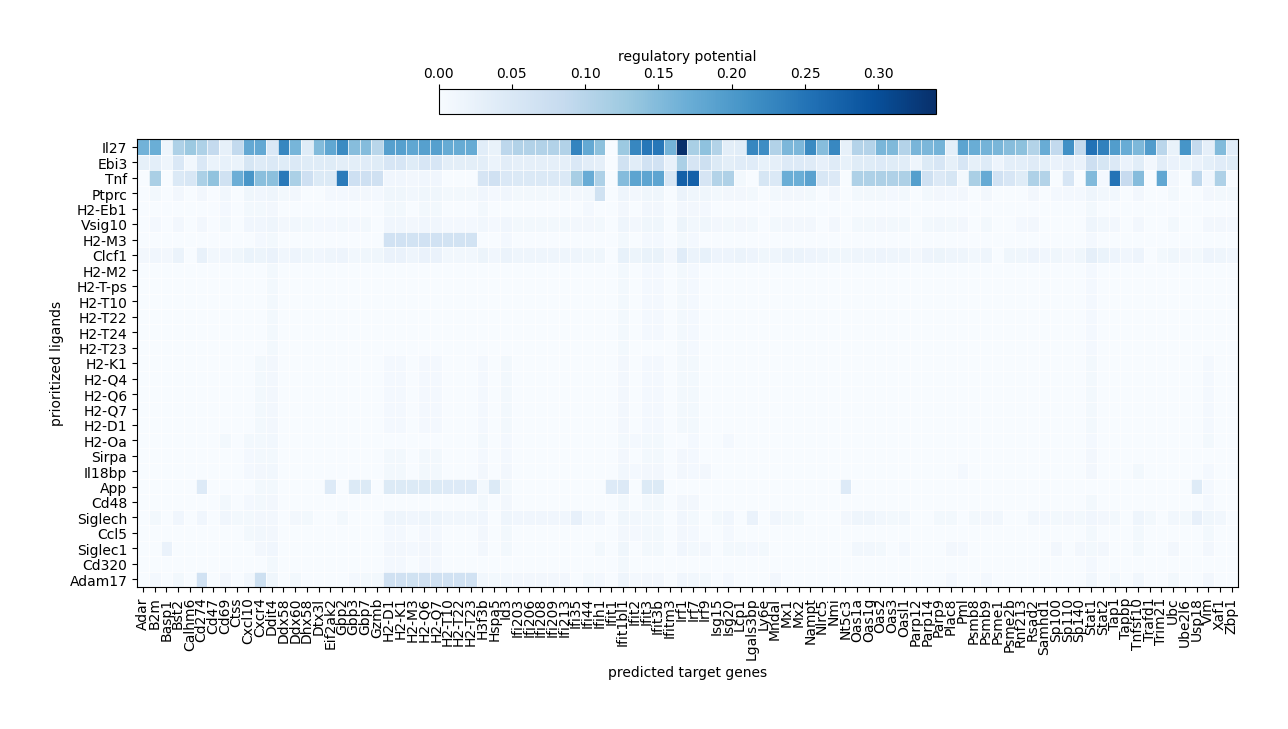

In [22]:
row2id = dict(zip(targets, range(len(targets))))
col2id = dict(zip(ligands, range(len(ligands))))
ligands = [
    x[1] for x in sorted(
        ((best_upstream_ligands.index(e), e) for e in ligands),
        key=lambda x : x[0],
        reverse=True
    )
]
targets.sort()
ligand_target_vis = subset_matrix(
    ligand_target_vis,
    rows=[row2id[e] for e in targets],
    cols=[col2id[e] for e in ligands]
)
fig, ax = heatmap_2d(
    ligand_target_vis.transpose(),
    xlabels=targets,
    ylabels=ligands,
    xtitle="predicted target genes",
    ytitle="prioritized ligands",
    cbar_label="regulatory potential",
    cmap="Blues",
    figsize=(12, 6)
)
plt.show()

21) Create a heatmap for ligand-receptor interactions (Figure 3c).

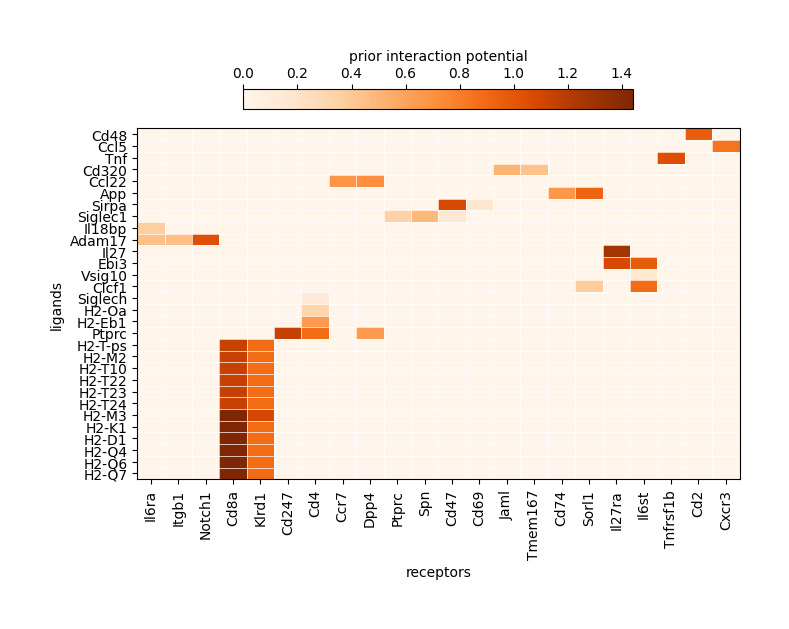

In [23]:
ligand_receptor_links = get_weighted_ligand_receptor_links(
    best_upstream_ligands,
    expressed_receptors,
    lr_network,
    lr_sig
)
mat, ligands, receptors = prepare_ligand_receptor_visualization(ligand_receptor_links)
fig, ax = heatmap_2d(
    mat,
    xlabels=receptors,
    ylabels=ligands,
    xtitle="receptors",
    ytitle="ligands",
    cbar_label="prior interaction potential",
    cmap="Oranges",
    figsize=(7, 5)
)
plt.show()

22) For each cell type, compute the log-fold change of the top-ranked ligands between treatment conditions.

In [24]:
lfcs = combine_by_key(*(
    get_lfc_celltype(
        ann,
        celltype,
        "aggregate",
        condition_oi="LCMV",
        condition_ref="SS",
        layer="data",
        features=best_upstream_ligands
    )
    for celltype in sender_celltypes
))
# sort by ligand activity
ligands, vals = zip(*(
    (ligand, metrics_vals[1])
    for ligand, metrics_vals in
    sorted(
        combine_dicts(ligand_activities, lfcs).items(),
        key=lambda x : x[1][0]["aupr_corrected"],
        reverse=True
    )
))

23) Create the heatmap (Figure 3d).

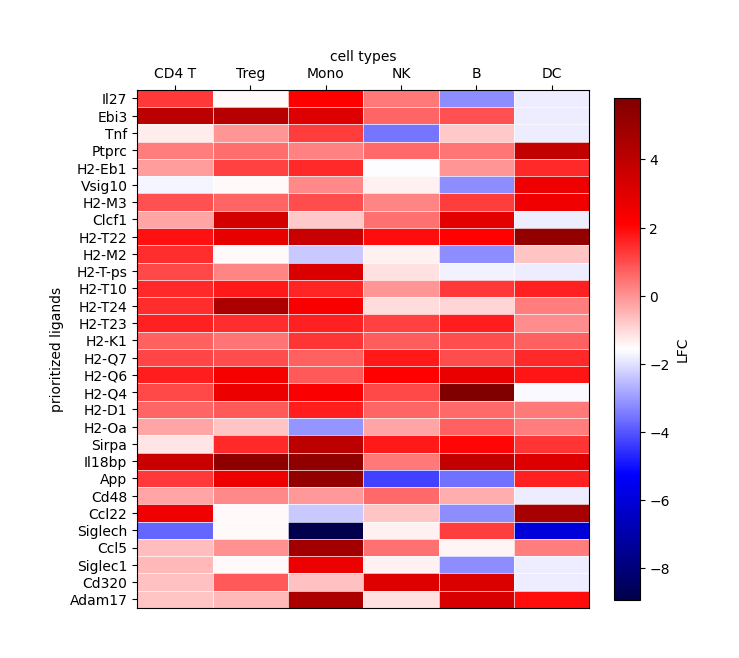

In [25]:
fig, ax = heatmap_2d(
    np.vstack(vals),
    xlabels=sender_celltypes,
    ylabels=ligands,
    xtitle="cell types",
    ytitle="prioritized ligands",
    cbar_label="LFC",
    cbar_position="right",
    cbar_orientation="vertical",
    cmap="seismic",
    figsize=(6, 6)
)
ax.invert_yaxis()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 
plt.show()

24) Create a dot plot showing the average expression of ligands per cell type, as well as the percentage of cells from the cell type expressing the ligands (Figure 3e).

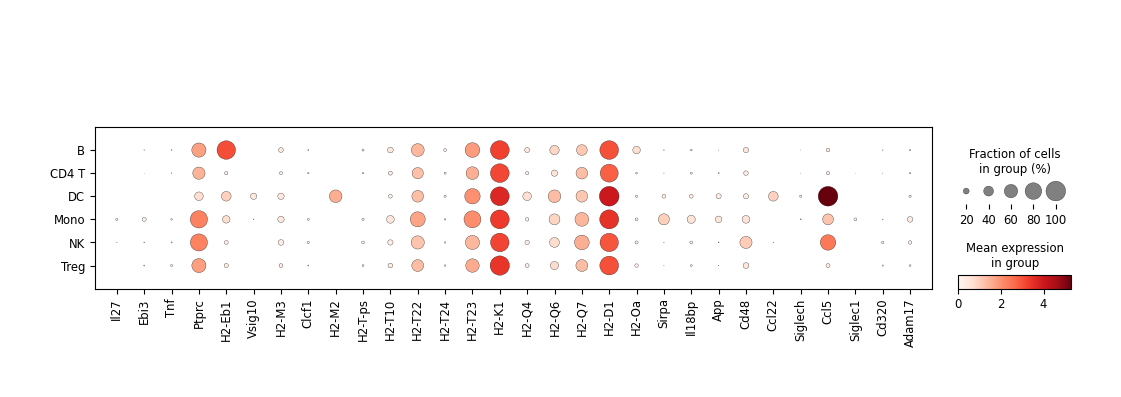

In [26]:
sub_ann = subset_ann(
    ann,
    val=sender_celltypes,
    val_col="celltype",
    layers=["data"]
)
sub_ann.var = ann.var
sub_ann.X = sub_ann.layers["data"]
sc.pl.dotplot(
    sub_ann,
    var_names=best_upstream_ligands,
    groupby="celltype",
    gene_symbols="gene"
)

25) To create a ligand-target chord diagram, assign each ligand to a specific cell type.

In [27]:
# the best upstream ligands are not necessarily present in the AnnData object
ligand_type_indication = assign_ligands_to_celltype(ann, sorted(set(best_upstream_ligands).intersection(ann.var_names)))
ligand_type_indication

,ligand_type,ligand
0,B,H2-Eb1
1,B,H2-M3
2,B,H2-Oa
3,B,H2-T24
4,B,Cd320
5,CD8 T,Clcf1
6,DC,H2-Q6
7,DC,Ccl5
8,DC,H2-T23
9,DC,H2-K1


26) Using the weighted ligand-target data frame from Step 16, group target genes and filter out the lowest 40% of the regulatory potentials. In this case, there is only one grouping of target genes (DE genes after LCMV infection), but users can define multiple target gene groups if applicable. In case the resulting chord diagram is still overcrowded, users may adjust the cutoff parameter to filter out even more ligand-target links.

In [28]:
quantile_cutoff = 0.4
active_ligand_target_links = pd.DataFrame(
    active_ligand_target_links,
    columns=("ligand", "target", "weight")
)
df = active_ligand_target_links.merge(ligand_type_indication, how="inner")
cutoff = np.quantile(df["weight"], quantile_cutoff)
circos_df = df[df["weight"] > cutoff]
circos_ligands = set(circos_df["ligand"])
circos_targets = set(circos_df["target"])
circos_links = df[
    [
        l in circos_ligands and t in circos_targets
        for l, t in zip(df["ligand"], df["target"])
    ]
]

27) Assign colors to cell types and target gene groups. Then, prepare the data frame for visualization: the function assigns colors to ligands and targets and calculates gaps between sectors of the chord diagram.

In [29]:
colors = {
    "General": "#377EB8",
    "NK": "#4DAF4A",
    "B": "#984EA3",
    "Mono": "#FF7F00",
    "DC": "#FFFF33",
    "Treg": "#F781BF",
    "CD8 T": "#E41A1C",
    "target": "#999999"
}

28) Draw the chord diagram (Figure 3g).

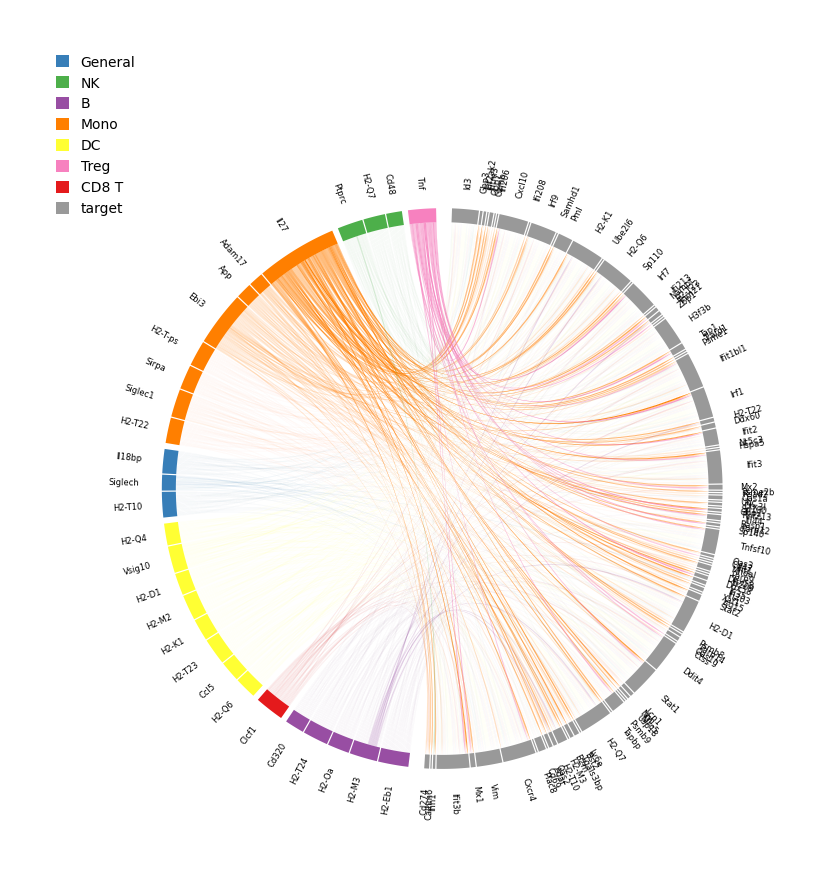

In [30]:
_ = create_ligand_links_circos_plot(
    circos_links,
    colors=colors,
    dest_name="target",
    opacity=circos_links["weight"],
    sender_receiver_space=8
)

29) To create a ligand-receptor chord diagram, we can perform similar steps
as above using the weighted ligand-receptor dataframe instead. 

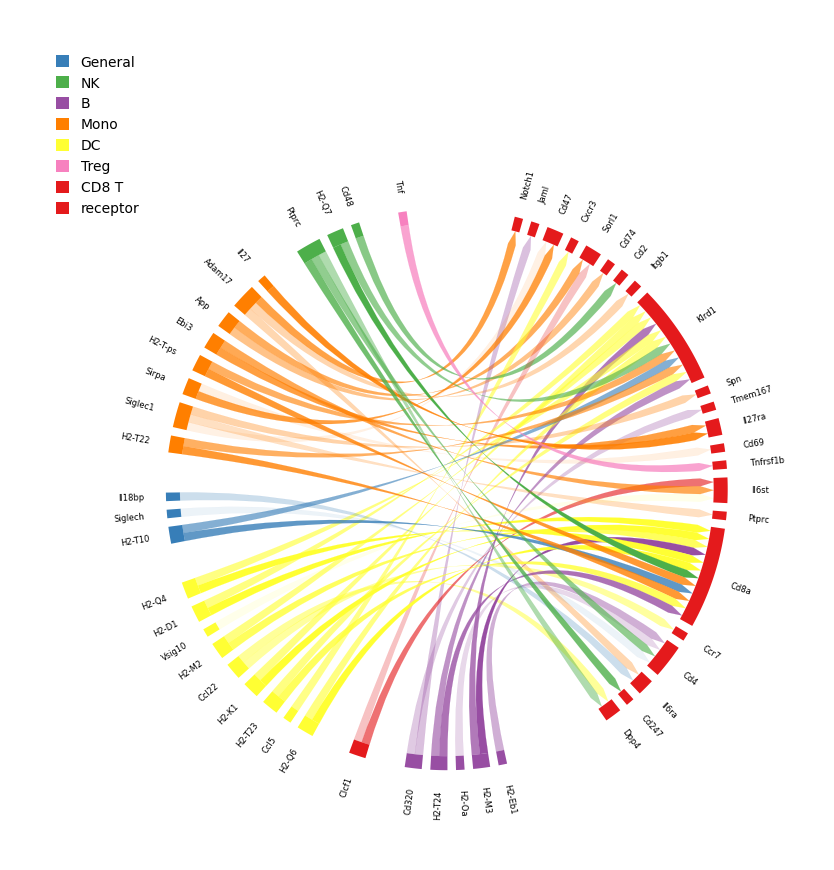

In [31]:
lr_circos_links = pd.DataFrame(
    ligand_receptor_links._mapping,
    columns=("ligand", "receptor", "weight")
).merge(ligand_type_indication, how="inner")
_ = create_ligand_links_circos_plot(
    lr_circos_links,
    colors={
        "General": "#377EB8",
        "NK": "#4DAF4A",
        "B": "#984EA3",
        "Mono": "#FF7F00",
        "DC": "#FFFF33",
        "Treg": "#F781BF",
        "CD8 T": "#E41A1C",
        "receptor": "#E41A1C"
    },
    dest_name="receptor",
    opacity=lr_circos_links["weight"],
    sender_receiver_space=8
)

30) To create a signaling graph, first download the ligand-transcription factor matrix. Then, extract the most highly weighted paths from the ligand to the target genes of interest. The number of regulators that are extracted can be adjusted using top_n_regulators. By setting minmax_scaling = TRUE, we perform min-max scaling to make the weights between the signaling and gene regulatory network more comparable. Additionally, it is possible to check which data sources support the inferred pathway by using the function infer_supporting_datasources. This would require separate signaling and gene regulatory networks as input.

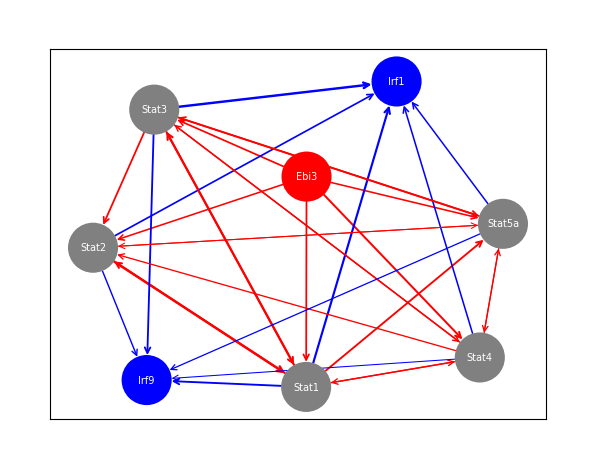

In [32]:
model_path = os.path.normpath("./tutorial_files")
if not os.path.exists(model_path):
    os.makedirs(model_path)
for filename in (
    ["ltf_matrix_mouse.pkl"]
):
    file_path = os.path.join(model_path, filename)
    if not os.path.exists(file_path):
        res = requests.get(f"https://zenodo.org/records/15131577/files/{filename}")
        with open(file_path, "wb") as file:
            file.write(res.content)
with open("./tutorial_files/ltf_matrix_mouse.pkl", "rb") as file:
    ltf_matrix = pickle.loads(file.read())
row_names = ltf_matrix["row_names"]
col_names = ltf_matrix["col_names"]
ltf_matrix = ltf_matrix["mat"]
ligands_oi = ["Ebi3"]
targets_oi = ["Irf1", "Irf9"]
lr_sig_df = pd.DataFrame(model["lr_sig"]._mapping, columns=["from", "to", "weight"])
gr_df = pd.DataFrame(model["gr"]._mapping, columns=["from", "to", "weight"])
tf_signaling, tf_regulatory = get_ligand_signaling_path(
    ltf_matrix,
    ligands_oi,
    targets_oi,
    row_names,
    col_names,
    lr_sig_df,
    gr_df,
    top_n_regulators=4,
    minmax_scaling=True
)
visualize_ligand_signaling_graph(
    tf_signaling,
    tf_regulatory,
    ligands_oi,
    targets_oi
)

## Prioritization of ligand-receptor pairs

This section is only applicable for the sender-focused approach. Whereas Step 12 prioritizes ligands only on the basis of their activity through target gene expression, this section incorporates relative expression and differential expression to further prioritize LR pairs associated with specific sender and receiver cell types. 

31) Filter the ligand-receptor network to only contain expressed interactions.

In [33]:
lr_network_filtered = lr_network.subset_sep(expressed_ligands, expressed_receptors)

32) Calculate the values required for prioritization, including DE between cell types, average expression, and DE between conditions. To use the wrapper function, follow option A. To calculate these values step-by-step, follow option B.

A. Using the wrapper function.

(i) Run the wrapper function. In case of steady-state datasets, use case_control=False.

In [34]:
info_tables = generate_info_tables(
    ann,
    "celltype",
    sender_celltypes,
    ["CD8 T"],
    lr_network_filtered,
    "aggregate",
    "LCMV",
    "SS",
    case_control=True
)

(ii) Assign the output of the wrapper function to variables.

In [35]:
sender_receiver_info = info_tables["sender_receiver_info"]
sender_receiver_de = info_tables["sender_receiver_de"]
lr_condition_de = info_tables["lr_condition_de"]

(B) Running step-by-step calculations.

(i) Calculate DE between cell types within the condition of interest. 

In [36]:
features = lr_network_filtered.get_ligands().union(lr_network_filtered.get_receptors())
sender_receiver_de = calculate_de(
    ann,
    "celltype",
    "LCMV",
    "aggregate",
    features=features
)


(ii) Calculate average expression of each gene per cell type.

In [37]:
sender_receiver_info = get_avg_exp(
    ann,
    "celltype",
    "LCMV",
    "aggregate",
    features=features
)

(iii) Calculate DE between conditions.

In [38]:
group_metrics(
    ann,
    groupby="aggregate",
    group_oi="LCMV",
    group_ref="SS",
    features=features,
    pval_thresh=0.01
)
lr_condition_de = ann.uns["group_metrics"][["gene", "lfc", "pval", "pval_adj"]]

(iv) Process the data frames from Steps (i)-(iii) to follow the same format. This function converts the input into a table containing sender-ligand-receptor-receiver columns (for cell type DE and expression values) or LR columns (for condition DE values).

In [39]:
sender_receiver_de = process_table_to_ic(
    sender_receiver_de,
    "celltype_DE",
    lr_network_filtered,
    sender_celltypes,
    ["CD8 T"]
)
sender_receiver_info = process_table_to_ic(
    sender_receiver_info,
    "expression",
    lr_network_filtered
)
lr_condition_de = process_table_to_ic(
    lr_condition_de,
    "group_DE",
    lr_network_filtered
)

33) Transform the sender column into a factor to ensure consistent cell type ordering across plots. Generate the prioritization table containing rankings of cell-type-specific, ligand-receptor interactions. The "case_control" scenario sets all weights to one, whereas the "one_condition" scenario sets condition specificity to zero and the remaining weights to one.

In [40]:
prior_table = generate_prioritization_table(
    sender_receiver_info,
    sender_receiver_de,
    ligand_activities_sorted,
    lr_condition_de
)

c:\Users\victorm\Documents\nichenetpy\.hatch\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


Users may provide custom weights in a dictionary. 

In [41]:
prioritizing_weights = {
    "de_ligand": 1,
    "de_receptor": 1,
    "activity_scaled": 1,
    "exprs_ligand": 1,
    "exprs_receptor": 1,
    "ligand_condition_specificity": 1,
    "receptor_condition_specificity": 1
}

## Prioritizing LR pairs across multiple receiver cell types

Because NicheNet runs on one receiver cell type at a time, prioritizing LR pairs across multiple receiver cell types requires rerunning the analysis for each cell type. Here, we use the wrapper function to run NicheNet for each T cell subtype as the receiver. Then, the relevant DE and expression tables for prioritization can be calculated for each receiver cell type. Finally, we concatenate all the tables and perform the prioritization.

In [42]:
nichenet_output = dict()
for receiver in ("CD8 T", "CD4 T", "Treg"):
    res = run_nichenet(
        ann,
        predictor,
        lr_network,
        receiver,
        "aggregate",
        "LCMV",
        "SS",
        sender_celltypes=sender_celltypes,
        expression_pct=0.05
    )
    ligand_activities = ligand_activities_df(res["ligand_activities_sorted_focused"])
    ligand_activities["receiver"] = [receiver for _ in range(len(ligand_activities.index))]
    res["ligand_activities"] = ligand_activities
    nichenet_output[receiver] = res

C:\Users\victorm\Documents\nichenetpy\src\nichenetpy\metrics.py:160: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.


In [43]:
for receiver, res in nichenet_output.items():
    lr_network_filtered = lr_network.subset_sep(
        res["ligand_activities"].index,
        [gene for gene in res["expressed_genes_receiver"] if gene in predictor.row_names]
    )
    res["info_tables"] = generate_info_tables(
        ann,
        "celltype",
        sender_celltypes,
        [receiver],
        lr_network_filtered,
        "aggregate",
        "LCMV",
        "SS",
        case_control=True
    )
info_tables_combined = {
    key: pd.concat((res["info_tables"][key] for res in nichenet_output.values()))
    for key in ["sender_receiver_de", "sender_receiver_info", "lr_condition_de"]
}
info_tables_combined["sender_receiver_info"].drop_duplicates(inplace=True)
info_tables_combined["lr_condition_de"].drop_duplicates(inplace=True)
ligand_activities_combined = pd.concat((res["ligand_activities"] for res in nichenet_output.values()))
prior_tables_combined = generate_prioritization_table(
    info_tables_combined["sender_receiver_info"],
    info_tables_combined["sender_receiver_de"],
    ligand_activities_combined,
    info_tables_combined["lr_condition_de"]
)

c:\Users\victorm\Documents\nichenetpy\.hatch\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


## Constructing your own prior model

Because the NicheNet prior model was constructed by integrating ligand-receptor, signaling, and gene regulatory databases, it is possible to replace each of these networks with external data sources. Constructing a customized prior model thus requires three directed networks. The source column contains the originating database of the interaction. As the reliability of each database can vary, we optimized the weights of each data source based on our validation procedure (as explained in Comparison with other methods). These optimized weights, along with hyperparameters for model construction (hyperparameter_list), are provided in the NicheNet package. Key hyperparameters include correction factors for dominant hubs in the ligand-signaling and gene regulatory networks, as well as the central damping factor of the Personalized PageRank algorithm, the network propagation mechanism used to determine the ligand-target regulatory potential.

In [44]:
network_path = os.path.normpath("./tutorial_files/model_construction/human")
if not os.path.exists(network_path):
    os.makedirs(network_path)
for filename in (
    "gr_human.csv",
    "lr_network_human.csv",
    "lr_sig_human.csv",
    "optimized_source_weights.csv",
    "annotation_data_sources.csv"
):
    file_path = os.path.join(network_path, filename)
    if not os.path.exists(file_path):
        res = requests.get(f"https://zenodo.org/records/14929618/files/{filename}")
        with open(file_path, "wb") as file:
            file.write(res.content)

In [45]:
gr_network = pd.DataFrame(read_csv_cols(os.path.join(network_path, "gr_human.csv")))
lr_network = pd.DataFrame(read_csv_cols(os.path.join(network_path, "lr_network_human.csv")))
sig_network = pd.DataFrame(read_csv_cols(os.path.join(network_path, "lr_sig_human.csv")))
source_weights = dict(zip(set(chain(gr_network["source"], lr_network["source"], sig_network["source"])), repeat(1)))
weighted_networks = construct_weighted_networks(
    lr_network,
    sig_network,
    gr_network,
    source_weights
)
weighted_networks["lr_sig"] = apply_hub_correction(weighted_networks["lr_sig"], hub=0.115)
weighted_networks["gr"] = apply_hub_correction(weighted_networks["gr"], hub=0.0803)

In this example, we will calculate target gene regulatory potential scores for TNF and the combination TNF+IL6.

In [46]:
ligands = [["TNF"], ["TNF", "IL6"]]
mat, row_names, col_names = construct_ligand_target_matrix(
    weighted_networks,
    lr_network,
    ligands,
    damping_factor=0.789,
    ltf_cutoff=0.926
)

A frequent use case is one where users are interested in replacing the ligand-receptor network in NicheNet with those of expression permutation tools in order to make their results more comparable. To achieve this, we recommend employing LIANA (Dimitrov et al., 2022), a comprehensive CCC framework that integrates both resources and computational algorithms for ligand-receptor interaction inference. The show_resources function is used to check which resources are present in LIANA, and select_resource returns a data frame of the interactions in that resource. The decomplexify function of LIANA is necessary for this integration, as it separate receptors into their respective subunits. Note that unlike before, source_weights_df only represents unoptimized weights, where the weight of every data source is 1.

In [47]:
liana_db = decomplexify(select_resource("cellphonedb"))
liana_db.rename(columns={
    "ligand": "from",
    "receptor": "to"
}, inplace=True)
liana_db["source"] = list(repeat("liana", len(liana_db)))
source_weights["liana"] = 1
weighted_networks = construct_weighted_networks(
    liana_db,
    sig_network,
    gr_network,
    source_weights
)

## Assessing the quality of predicted ligands

We can assess the quality of the prioritized ligands by constructing a random forest model to solve a binary classification problem: determining whether a particular gene belongs to the gene set of interest or the background gene set. The predictors of the model are the regulatory potential scores of the top 30 predicted ligands, while the target is a binary indicator of a gene's membership in the gene set of interest. This target variable is the same as the OEP described in the ligand activity analysis algorithm. We perform stratified k -fold cross-validation, in which in each fold, 1 / k of the genes are isolated as "unseen data." The stratified split ensures that each fold maintains the same proportion of the gene set of interest and background genes as in the original gene sets. The model is trained on the remaining ( k − 1 ) / k of the genes to evaluate how well the 30 ligands can classify genes as belonging to the gene set of interest. The model's performance can then be evaluated by using classification metrics like AUPR and AUROC or by applying Fisher's exact test on the confusion matrix. A high performance suggests that the identified ligands are highly specific to the CCC event of interest.

In [48]:
n = 2
k = 3
gene_predictions_top30_list = [
    assess_rf_class_probabilities(
        folds=k,
        geneset=geneset,
        background_expressed_genes=expressed_genes_receiver,
        ligands_oi=ligands_oi,
        predictor=predictor
    ) for _ in range(n)
]
target_prediction_performances = []
for df in gene_predictions_top30_list:
    met = calculate_metrics(list(df["prediction"]), list(df["response"]))
    target_prediction_performances.append(pd.DataFrame([list(met.values())], columns=met.keys()))
target_prediction_performances = pd.concat(target_prediction_performances)
target_prediction_performances.reset_index(drop=True, inplace=True)
target_prediction_performances.mean()

auroc             0.712343
pearson           0.291869
aupr              0.269435
aupr_corrected    0.194542
dtype: float64

In [49]:
target_prediction_performances_discrete = pd.concat([calculate_fraction_top_predicted(df) for df in gene_predictions_top30_list])
target_prediction_performances_discrete

,true_target,n,positive_prediction,fraction_positive_predicted
0,0,3224,116,0.035980
1,1,261,60,0.229885
0,0,3224,116,0.035980
1,1,261,60,0.229885


In [50]:
target_prediction_performances_discrete[
    target_prediction_performances_discrete["true_target"] == 1
]["fraction_positive_predicted"].mean()

np.float64(0.22988505747126436)

In [51]:
target_prediction_performances_discrete[
    target_prediction_performances_discrete["true_target"] == 0
]["fraction_positive_predicted"].mean()

np.float64(0.03598014888337469)

In [52]:
target_prediction_performances_discrete_fisher = [
    calculate_fraction_top_predicted_fisher(e).pvalue for e in gene_predictions_top30_list
]
sum(target_prediction_performances_discrete_fisher)/len(target_prediction_performances_discrete_fisher)

np.float64(1.95463008502739e-26)

In [53]:
dfs = []
for round, affected_gene_predictions in enumerate(gene_predictions_top30_list):
    df = get_top_predicted_genes(affected_gene_predictions)
    df.rename(columns={"predicted_top_target": f"predicted_top_target_round{round}"}, inplace=True)
    dfs.append(df)
top_predicted_genes = dfs[0]
for df in dfs[1:]:
    top_predicted_genes = top_predicted_genes.merge(df, on=["gene", "true_target"], how="outer")
top_predicted_genes[top_predicted_genes["true_target"] == 1]

,gene,true_target,predicted_top_target_round0,predicted_top_target_round1
5,1600014C10Rik,1,False,False
14,2410006H16Rik,1,True,False
45,Acadl,1,False,False
58,Actb,1,False,False
70,Adar,1,True,False
...,...,...,...,...
3395,Xpo1,1,False,False
3418,Zbp1,1,True,False
3445,Zfas1,1,False,False
3473,Znfx1,1,False,False


In [54]:
session_info.show()